# FAST Training Runs — Data Condition Experiments

11 training configurations using our evaluation method (shuffled 5-fold KFold + official test set):

| Run | Train Data | Augmentation | Early Stopping | Description |
|-----|-----------|:------------:|:--------------:|-------------|
| 1 | Original (A) | ✗ | patience=20 | Raw train+val+test from BCIC2020Track3 |
| 2 | Condition B | ✗ | patience=20 | ICA-cleaned, ALL delta-dominant ICs removed |
| 3 | Condition C | ✗ | patience=20 | ICA-cleaned, only artifact delta ICs removed |
| 4 | A + B | ✗ | patience=20 | Original + no-delta combined |
| 5 | A + C | ✗ | patience=20 | Original + no-artifacts combined |
| 6 | A + B + C | ✗ | patience=20 | All three conditions combined |
| 7 | B + C | ✗ | patience=20 | Both ICA conditions combined |
| 8 | Original (A) | ✓ | patience=20 | Jitter + Noise + Dropout + Cool Down |
| 9 | Original (A) | ✓ | ✗ (full 200 ep) | Same augmentation, no early stopping |
| 10 | Original (A) | ✓ | ✗ (full 200 ep) | Kaggle replication: BS=16, FP32, no CV |
| 11 | High-pass 4 Hz | ✗ | patience=20 | Strict per-channel high-pass filtered dataset |

In [1]:
import os
import sys
import h5py
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import logging

torch.set_num_threads(8)
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
from transformers import PretrainedConfig
import lightning as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, Callback

logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)
logging.getLogger('lightning').setLevel(logging.WARNING)

# Project imports
sys.path.insert(0, os.path.abspath('..'))
from fast.models import FAST
from fast.data import BasicDataset, Electrodes, Zones, SUBJECTS, CLASSES
from fast.train import EEG_Encoder_Module, inference_on_loader, HistoryCallback
from fast.utils import seed_all

print(f'Subjects: {SUBJECTS}')
print(f'Classes: {CLASSES}')
print(f'Electrodes: {len(Electrodes)} channels')

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subjects: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15']
Classes: ['hello', 'help-me', 'stop', 'thank-you', 'yes']
Electrodes: 64 channels


## 1. Configuration

In [2]:
# ============================================================
# Global configuration
# ============================================================
GPU_ID = 0
SEED = 42
MAX_EPOCHS = 200
BATCH_SIZE = 128
N_FOLDS = 5
NUM_WORKERS = 4
PRECISION = 'bf16-mixed'

# Data paths
H5_ORIGINAL = '../Processed/BCIC2020Track3.h5'
H5_COND_B   = '../Processed/BCIC2020Track3_ICA_no_delta.h5'
H5_COND_C   = '../Processed/BCIC2020Track3_ICA_no_artifacts.h5'
H5_HP4      = '../Processed/BCIC2020Track3_highpass_4hz.h5'
H5_TEST     = '../Processed/BCIC2020Track3_Test.h5'

# Base output directory
RESULTS_BASE = '../results/condition_experiments'

# FAST model config
SFREQ = 250
MODEL_CONFIG = PretrainedConfig(
    electrodes=Electrodes,
    zone_dict=Zones,
    dim_cnn=32,
    dim_token=32,
    seq_len=800,
    window_len=SFREQ,
    slide_step=SFREQ // 2,
    head='Conv4Layers',
    n_classes=5,
    num_layers=4,
    num_heads=8,
    dropout=0.1,
)

seed_all(SEED)

## 2. Data Loading Utilities

In [3]:
# ============================================================
# 2a. Build strict 4Hz high-pass condition dataset (Run 11)
# ============================================================
import scipy.signal as sps


def create_highpass_4hz_dataset(input_h5, output_h5, sfreq=250, cutoff_hz=4.0, order=4):
    """Create a strict per-channel high-pass (4 Hz) version of the original H5 dataset."""
    if os.path.exists(output_h5):
        print(f'HP4 dataset already exists: {output_h5}')
        return

    nyq = sfreq / 2.0
    wn = cutoff_hz / nyq
    sos = sps.butter(order, wn, btype='highpass', output='sos')

    os.makedirs(os.path.dirname(output_h5), exist_ok=True)
    with h5py.File(input_h5, 'r') as f_in, h5py.File(output_h5, 'w') as f_out:
        for sid in sorted(f_in.keys()):
            X = f_in[sid]['X'][()].astype(np.float32)  # (n_trials, n_ch, n_time)
            Y = f_in[sid]['Y'][()].astype(np.uint8)

            X_hp = np.empty_like(X, dtype=np.float32)
            for trial_idx in range(X.shape[0]):
                X_hp[trial_idx] = sps.sosfiltfilt(sos, X[trial_idx], axis=1).astype(np.float32)

            grp = f_out.create_group(sid)
            grp.create_dataset('X', data=X_hp)
            grp.create_dataset('Y', data=Y)

            print(
                f'  S{sid}: X{X.shape} -> HP4 range [{X_hp.min():.1f}, {X_hp.max():.1f}]'
            )

    print(f'\nCreated HP4 dataset: {output_h5}')


create_highpass_4hz_dataset(H5_ORIGINAL, H5_HP4, sfreq=SFREQ, cutoff_hz=4.0, order=4)

HP4 dataset already exists: ../Processed/BCIC2020Track3_highpass_4hz.h5


In [4]:
def load_h5_subject(h5_path, sid):
    """Load X, Y for a single subject from an H5 file."""
    with h5py.File(h5_path, 'r') as f:
        X = f[sid]['X'][()].astype(np.float32)
        Y = f[sid]['Y'][()].astype(np.uint8)
    return X, Y


def load_test_h5(h5_path):
    """Load test data for all subjects from the test H5 file."""
    test_data = {}
    with h5py.File(h5_path, 'r') as f:
        for sid in f.keys():
            X = f[sid]['X'][()].astype(np.float32)
            Y = f[sid]['Y'][()].astype(np.uint8)
            test_data[sid] = (X, Y)
    return test_data


def load_combined_subject(h5_paths, sid):
    """Load and concatenate data for one subject from multiple H5 files."""
    X_parts, Y_parts = [], []
    for path in h5_paths:
        X, Y = load_h5_subject(path, sid)
        X_parts.append(X)
        Y_parts.append(Y)
    return np.concatenate(X_parts, axis=0), np.concatenate(Y_parts, axis=0)


# Verify all files exist
for name, path in [('Original', H5_ORIGINAL), ('Cond B', H5_COND_B),
                   ('Cond C', H5_COND_C), ('HP4', H5_HP4), ('Test', H5_TEST)]:
    assert os.path.exists(path), f'{name} not found: {path}'
    print(f'{name}: {path} OK')

# Preload ALL data into memory (avoids redundant disk I/O across runs)
print('Preloading all data into memory...')
_DATA_CACHE = {}
for _path in [H5_ORIGINAL, H5_COND_B, H5_COND_C, H5_HP4]:
    _DATA_CACHE[_path] = {}
    with h5py.File(_path, 'r') as f:
        for sid in f.keys():
            _DATA_CACHE[_path][sid] = (
                f[sid]['X'][()].astype(np.float32),
                f[sid]['Y'][()].astype(np.uint8),
            )
    print(f'  Cached {os.path.basename(_path)}: {len(_DATA_CACHE[_path])} subjects')


def load_combined_subject_cached(h5_paths, sid):
    """Load and concatenate from cache."""
    X_parts, Y_parts = [], []
    for path in h5_paths:
        X, Y = load_h5_subject_cached(path, sid)
        X_parts.append(X)
        Y_parts.append(Y)
    return np.concatenate(X_parts, axis=0), np.concatenate(Y_parts, axis=0)


def load_h5_subject_cached(h5_path, sid):
    """Load from in-memory cache instead of disk."""
    return _DATA_CACHE[h5_path][sid]


# Preload ALL data into memory (avoids redundant disk I/O across runs)
print('Preloading all data into memory...')
_DATA_CACHE = {}
for _path in [H5_ORIGINAL, H5_COND_B, H5_COND_C, H5_HP4]:
    _DATA_CACHE[_path] = {}
    with h5py.File(_path, 'r') as f:
        for sid in f.keys():
            _DATA_CACHE[_path][sid] = (
                f[sid]['X'][()].astype(np.float32),
                f[sid]['Y'][()].astype(np.uint8),
            )
    print(f'  Cached {os.path.basename(_path)}: {len(_DATA_CACHE[_path])} subjects')


def load_h5_subject_cached(h5_path, sid):
    """Load from in-memory cache instead of disk."""
    return _DATA_CACHE[h5_path][sid]


def load_combined_subject_cached(h5_paths, sid):
    """Load and concatenate from cache."""
    X_parts, Y_parts = [], []
    for path in h5_paths:
        X, Y = load_h5_subject_cached(path, sid)
        X_parts.append(X)
        Y_parts.append(Y)
    return np.concatenate(X_parts, axis=0), np.concatenate(Y_parts, axis=0)


# Load test data once (shared across all runs)
test_per_subject = load_test_h5(H5_TEST)
print(f'\nTest set loaded: {len(test_per_subject)} subjects, '
      f'{test_per_subject["01"][0].shape[0]} trials each')


Original: ../Processed/BCIC2020Track3.h5 OK
Cond B: ../Processed/BCIC2020Track3_ICA_no_delta.h5 OK
Cond C: ../Processed/BCIC2020Track3_ICA_no_artifacts.h5 OK
HP4: ../Processed/BCIC2020Track3_highpass_4hz.h5 OK
Test: ../Processed/BCIC2020Track3_Test.h5 OK
Preloading all data into memory...
  Cached BCIC2020Track3.h5: 15 subjects
  Cached BCIC2020Track3_ICA_no_delta.h5: 15 subjects
  Cached BCIC2020Track3_ICA_no_artifacts.h5: 15 subjects
  Cached BCIC2020Track3_highpass_4hz.h5: 15 subjects
Preloading all data into memory...
  Cached BCIC2020Track3.h5: 15 subjects
  Cached BCIC2020Track3_ICA_no_delta.h5: 15 subjects
  Cached BCIC2020Track3_ICA_no_artifacts.h5: 15 subjects
  Cached BCIC2020Track3_highpass_4hz.h5: 15 subjects

Test set loaded: 15 subjects, 50 trials each


## 3b. Data Augmentation Classes

Used by Runs 8 and 9. Augmentation probabilities decay linearly (cool-down) from epoch 170 to 200.

In [4]:
class AugmentedDataset(BasicDataset):
    """Training dataset with stochastic augmentations and epoch-based cool-down."""

    def __init__(self, data, label, temporal_jitter=True, gaussian_noise=True, channel_dropout=True):
        # Store raw NumPy arrays instead of converting to Tensor (avoids double conversion)
        if len(data.shape) == 4:
            data, label = np.concatenate(data, axis=0), np.concatenate(label, axis=0)
        self.data = data.astype(np.float32) if isinstance(data, np.ndarray) else data.numpy().astype(np.float32)
        self.labels = torch.from_numpy(label) if isinstance(label, np.ndarray) else torch.tensor(label)
        self.temporal_jitter = temporal_jitter
        self.gaussian_noise = gaussian_noise
        self.channel_dropout = channel_dropout
        self.current_epoch = 0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx].copy()  # Already NumPy float32
        y = self.labels[idx]

        # Cool down: linearly decay augmentation probability from epoch 170 to 200
        prob_mult = 1.0
        if self.current_epoch >= 170:
            if self.current_epoch >= 200:
                prob_mult = 0.0
            else:
                prob_mult = 1.0 - (self.current_epoch - 170) / 30.0

        # Temporal Jitter: +/- 15 samples (60ms at 250Hz), 50% chance
        if self.temporal_jitter and np.random.rand() < 0.5 * prob_mult:
            shift = np.random.randint(-15, 16)
            if shift > 0:
                x = np.pad(x, ((0, 0), (0, shift)), mode='constant')[:, shift:]
            elif shift < 0:
                x = np.pad(x, ((0, 0), (-shift, 0)), mode='constant')[:, :shift]

        # Gaussian Noise: SNR 20-40dB, 50% chance
        if self.gaussian_noise and np.random.rand() < 0.5 * prob_mult:
            snr_db = np.random.uniform(20, 40)
            signal_power = np.mean(x ** 2)
            noise_power = signal_power / (10 ** (snr_db / 10))
            noise = np.random.normal(0, np.sqrt(noise_power), x.shape)
            x = x + noise

        # Channel Dropout: Zero out 10% of channels, 30% chance
        if self.channel_dropout and np.random.rand() < 0.3 * prob_mult:
            n_channels = x.shape[0]
            mask = np.random.choice([0, 1], size=(n_channels, 1), p=[0.1, 0.9])
            x = x * mask

        return torch.from_numpy(x).float(), y


class AugmentationScheduler(Callback):
    """Updates AugmentedDataset.current_epoch at the start of each training epoch."""

    def on_train_epoch_start(self, trainer, pl_module):
        if hasattr(trainer.train_dataloader.dataset, 'current_epoch'):
            trainer.train_dataloader.dataset.current_epoch = trainer.current_epoch

## 3. Define the 11 Experiment Configurations

In [ ]:
EXPERIMENTS = {
    'run1_original': {
        'name': 'Run 1: Original Data (A)',
        'h5_paths': [H5_ORIGINAL],
        'output_dir': os.path.join(RESULTS_BASE, 'run1_original'),
    },
    'run2_condB': {
        'name': 'Run 2: Condition B (No Delta)',
        'h5_paths': [H5_COND_B],
        'output_dir': os.path.join(RESULTS_BASE, 'run2_condB'),
    },
    'run3_condC': {
        'name': 'Run 3: Condition C (No Artifacts)',
        'h5_paths': [H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run3_condC'),
    },
    'run4_A_B': {
        'name': 'Run 4: Original + Condition B',
        'h5_paths': [H5_ORIGINAL, H5_COND_B],
        'output_dir': os.path.join(RESULTS_BASE, 'run4_A_B'),
    },
    'run5_A_C': {
        'name': 'Run 5: Original + Condition C',
        'h5_paths': [H5_ORIGINAL, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run5_A_C'),
    },
    'run6_A_B_C': {
        'name': 'Run 6: Original + Cond B + Cond C',
        'h5_paths': [H5_ORIGINAL, H5_COND_B, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run6_A_B_C'),
    },
    'run7_B_C': {
        'name': 'Run 7: Condition B + Condition C',
        'h5_paths': [H5_COND_B, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run7_B_C'),
    },
    'run8_augment': {
        'name': 'Run 8: Augmentations + Cool Down',
        'h5_paths': [H5_ORIGINAL],
        'output_dir': os.path.join(RESULTS_BASE, 'run8_augment'),
    },
    'run9_augment_no_es': {
        'name': 'Run 9: Augmentations (No Early Stopping)',
        'h5_paths': [H5_ORIGINAL],
        'output_dir': os.path.join(RESULTS_BASE, 'run9_augment_no_es'),
    },
    'run10_kaggle_replication': {
        'name': 'Run 10: Kaggle Replication',
        'h5_paths': [H5_ORIGINAL],
        'output_dir': os.path.join(RESULTS_BASE, 'run10_kaggle_replication'),
    },
    'run11_highpass4': {
        'name': 'Run 11: High-pass 4 Hz',
        'h5_paths': [H5_HP4],
        'output_dir': os.path.join(RESULTS_BASE, 'run11_highpass4'),
    },
}

# Preview data sizes per experiment
print(f'{"Experiment":<35} {"Trials/Subject":<18} {"Total Trials"}')
print('-' * 70)
for key, exp in EXPERIMENTS.items():
    n_h5 = len(exp['h5_paths'])
    trials_per_subj = 350 * n_h5
    total = trials_per_subj * 15
    print(f'{exp["name"]:<35} {trials_per_subj:<18} {total}')

Experiment                          Trials/Subject     Total Trials
----------------------------------------------------------------------
Run 1: Original Data (A)            350                5250
Run 2: Condition B (No Delta)       350                5250
Run 3: Condition C (No Artifacts)   350                5250
Run 4: Original + Condition B       700                10500
Run 5: Original + Condition C       700                10500
Run 6: Original + Cond B + Cond C   1050               15750
Run 7: Condition B + Condition C    700                10500
Run 8: Augmentations + Cool Down    350                5250
Run 9: Augmentations (No Early Stopping) 350                5250


## 4. Training Function

Per-subject 5-fold CV with:
- Shuffled KFold (seed=42), seeded independently per run
- Mini-batch training (batch_size=64)
- Best model selection on val_acc
- Early stopping (patience=20, configurable)
- Official test set evaluation
- Learning curves (loss, accuracy, F1) + checkpoints saved per fold

In [6]:
def train_experiment(experiment_config, model_config, test_per_subject, patience=20, dataset_cls=BasicDataset):
    """
    Run a full training experiment: per-subject 5-fold CV with test evaluation.
    
    Parameters
    ----------
    experiment_config : dict
        Must contain 'name', 'h5_paths', 'output_dir'.
    model_config : PretrainedConfig
        FAST model configuration.
    test_per_subject : dict
        {SID: (X_test, Y_test)} for official test evaluation.
    patience : int
        Early stopping patience.
    dataset_cls : class
        Dataset class to use (BasicDataset or AugmentedDataset).
    
    Returns
    -------
    pd.DataFrame
        Per-subject results with Best_Val_Acc, Test_Acc, Test_F1.
    """
    exp_name = experiment_config['name']
    h5_paths = experiment_config['h5_paths']
    save_dir = experiment_config['output_dir']
    os.makedirs(save_dir, exist_ok=True)
    
    print(f'\n{"=" * 70}')
    print(f'  {exp_name}')
    print(f'  Data sources: {[os.path.basename(p) for p in h5_paths]}')
    print(f'  Output: {save_dir}')
    print(f'{"=" * 70}')
    
    subject_results = []
    global_pred = []
    global_true = []
    
    for SID in SUBJECTS:
        print(f'\n--- SUBJECT {SID} ---')
        
        # Load data (single or combined)
        if len(h5_paths) == 1:
            X_sub, Y_sub = load_h5_subject_cached(h5_paths[0], SID)
        else:
            X_sub, Y_sub = load_combined_subject_cached(h5_paths, SID)
        
        print(f'  Data: {X_sub.shape}, labels: {np.unique(Y_sub, return_counts=True)}')
        
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        fold_metrics = []
        best_fold_acc = -np.inf
        best_fold_f1 = float('nan')
        best_fold_ckpt = None
        best_train_len = 1
        
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_sub)):
            x_train, y_train = X_sub[train_idx], Y_sub[train_idx]
            x_val, y_val = X_sub[val_idx], Y_sub[val_idx]
            
            # Initialize dataset
            train_ds = dataset_cls(x_train, y_train)
            val_ds = BasicDataset(x_val, y_val) # Validation always on basic dataset

            train_loader = DataLoader(
                train_ds, batch_size=BATCH_SIZE,
                shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                val_ds, batch_size=BATCH_SIZE,
                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
            )
            
            model = EEG_Encoder_Module(model_config, MAX_EPOCHS, len(train_loader))
            model.model = torch.compile(model.model)  # JIT compile for faster training
            history_cb = HistoryCallback()
            
            fold_dir = os.path.join(save_dir, f'sub-{SID}')
            os.makedirs(fold_dir, exist_ok=True)
            
            callbacks = [history_cb]
            
            ckpt_cb = ModelCheckpoint(
                dirpath=fold_dir,
                filename=f'fold-{fold_idx}-best',
                monitor='val_acc',
                mode='max',
                save_top_k=1,
                verbose=False,
            )
            callbacks.append(ckpt_cb)
            
            if patience > 0:
                early_stop_cb = EarlyStopping(
                    monitor='val_acc',
                    min_delta=0.00,
                    patience=patience,
                    verbose=True,
                    mode='max'
                )
                callbacks.append(early_stop_cb)
                
            if dataset_cls == AugmentedDataset:
                callbacks.append(AugmentationScheduler())
            
            trainer = pl.Trainer(
                strategy='auto',
                accelerator='gpu',
                devices=[GPU_ID],
                max_epochs=MAX_EPOCHS,
                callbacks=callbacks,
                enable_progress_bar=True,
                enable_checkpointing=True,
                precision=PRECISION,
                logger=False,
                num_sanity_val_steps=0,
            )
            
            trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
            
            fold_best = float(ckpt_cb.best_model_score) if ckpt_cb.best_model_score is not None else float('nan')
            fold_metrics.append([fold_idx, fold_best])
            
            # Save learning curves
            if all(len(v) > 0 for v in history_cb.history.values()):
                min_len = min(len(v) for v in history_cb.history.values())
                clean_history = {k: v[:min_len] for k, v in history_cb.history.items()}
                pd.DataFrame(clean_history).to_csv(
                    os.path.join(fold_dir, f'fold-{fold_idx}_history.csv'), index_label='Epoch'
                )
                
                # Plot learning curves
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                
                axes[0].plot(clean_history.get('loss', []), label='Train Loss', color='blue')
                axes[0].plot(clean_history.get('val_loss', []), label='Val Loss', color='orange', linestyle='--')
                axes[0].set_title(f'Subject {SID} Fold {fold_idx+1} Loss')
                axes[0].set_xlabel('Epoch')
                axes[0].set_ylabel('Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                
                axes[1].plot(clean_history.get('acc', []), label='Train Acc', color='green')
                axes[1].plot(clean_history.get('val_acc', []), label='Val Acc', color='red', linestyle='--')
                axes[1].set_title(f'Subject {SID} Fold {fold_idx+1} Accuracy')
                axes[1].set_xlabel('Epoch')
                axes[1].set_ylabel('Accuracy')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                axes[2].plot(clean_history.get('f1', []), label='Train F1', color='purple')
                axes[2].plot(clean_history.get('val_f1', []), label='Val F1', color='magenta', linestyle='--')
                axes[2].set_title(f'Subject {SID} Fold {fold_idx+1} F1 Score')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('F1 (Macro)')
                axes[2].legend()
                axes[2].grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(fold_dir, f'fold-{fold_idx}_curves.png'), dpi=100)
                plt.close()
            
            print(f'  Fold {fold_idx+1}: best val_acc={fold_best:.4f}')
            
            if ckpt_cb.best_model_path and fold_best > best_fold_acc:
                best_fold_acc = fold_best
                # Get the val_f1 at the same epoch as best val_acc
                if 'val_f1' in history_cb.history and len(history_cb.history['val_f1']) > 0:
                    best_fold_f1 = history_cb.history['val_f1'][-1]
                best_fold_ckpt = ckpt_cb.best_model_path
                best_train_len = len(train_loader)
        
        # Save fold metrics
        df_folds = pd.DataFrame(fold_metrics, columns=['Fold', 'Best_Val_Acc'])
        df_folds.to_csv(os.path.join(save_dir, f'sub-{SID}', 'fold_metrics.csv'), index=False)
        
        # Load best fold model and evaluate on test set
        test_acc = np.nan
        test_f1 = np.nan
        
        if best_fold_ckpt:
            best_model = EEG_Encoder_Module.load_from_checkpoint(
                best_fold_ckpt,
                config=model_config,
                max_epochs=MAX_EPOCHS,
                niter_per_ep=best_train_len,
                weights_only=False,
            )
            subj_best_path = os.path.join(save_dir, f'sub-{SID}', 'best_subject.pth')
            torch.save(best_model.model.state_dict(), subj_best_path)
            
            # Official test set evaluation
            if SID in test_per_subject:
                X_test, Y_test = test_per_subject[SID]
                test_loader = DataLoader(
                    BasicDataset(X_test, Y_test), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
                )
                y_pred, y_true = inference_on_loader(best_model.model, test_loader)
                test_acc = accuracy_score(y_true, y_pred)
                test_f1 = f1_score(y_true, y_pred, average='macro')
                np.savetxt(
                    os.path.join(save_dir, f'sub-{SID}', 'test_predictions.csv'),
                    np.array([y_pred, y_true]).T, delimiter=',', fmt='%d',
                    header='Predicted,True'
                )
                global_pred.append(y_pred)
                global_true.append(y_true)
            
            print(f'  Best val_acc={best_fold_acc:.4f} | Test Acc={test_acc:.4f}, F1={test_f1:.4f}')
        else:
            print(f'  WARNING: No checkpoint saved for subject {SID}')
        
        subject_results.append([SID, best_fold_acc, best_fold_f1, test_acc, test_f1])
    
    # Save summary
    df_subjects = pd.DataFrame(
        subject_results, columns=['Subject', 'Best_Val_Acc', 'Best_Val_F1', 'Test_Acc', 'Test_F1']
    )
    df_subjects.to_csv(os.path.join(save_dir, 'summary_per_subject.csv'), index=False)
    
    # Save global predictions
    if global_pred and global_true:
        gp = np.concatenate(global_pred)
        gt = np.concatenate(global_true)
        np.savetxt(
            os.path.join(save_dir, 'global_test_predictions.csv'),
            np.array([gp, gt]).T, delimiter=',', fmt='%d', header='Predicted,True'
        )
    
    # Plot per-subject accuracy
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(df_subjects['Subject'], df_subjects['Test_Acc'],
                  color='skyblue', edgecolor='black')
    mean_acc = df_subjects['Test_Acc'].mean()
    ax.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_acc:.4f}')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{exp_name} — Test Accuracy per Subject', fontsize=14)
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, min(1.0, max(df_subjects['Test_Acc'].max(), mean_acc) * 1.15))
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'global_subject_accuracy.png'), dpi=150)
    plt.show()
    plt.close()
    
    print(f'\n{exp_name} COMPLETE')
    print(f'Mean Test Acc: {mean_acc:.4f} +/- {df_subjects["Test_Acc"].std():.4f}')
    print(f'Summary saved to {save_dir}/summary_per_subject.csv')
    
    return df_subjects


## 5. Run 1: Original Data (A)


  Run 1: Original Data (A)
  Data sources: ['BCIC2020Track3.h5']
  Output: ../results/condition_experiments/run1_original

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

  Fold 4: best val_acc=0.6714


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.171
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.186
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.243
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.286
Metric val_acc improved by 0.100 >= min_delta = 0.0. New best score: 0.386
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.400
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.414
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.443
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.486
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.529
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.571
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.629
Monitored metric val_acc did not improve in the last 20 records. Best score: 0.629. Signaling Trainer to stop.


  Fold 5: best val_acc=0.6286
  Best val_acc=0.7714 | Test Acc=0.7400, F1=0.7381


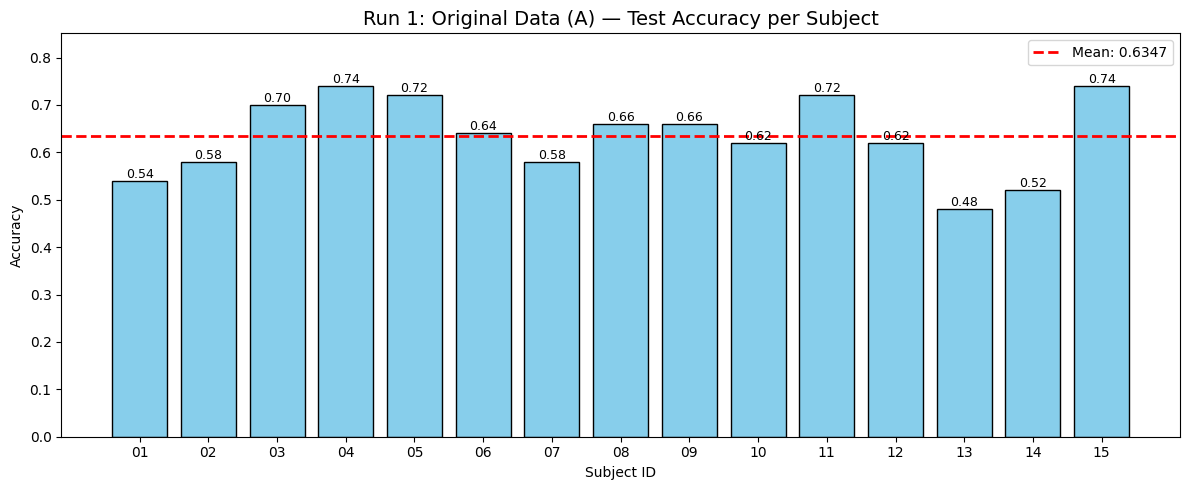


Run 1: Original Data (A) COMPLETE
Mean Test Acc: 0.6347 +/- 0.0823
Summary saved to ../results/condition_experiments/run1_original/summary_per_subject.csv


In [7]:
seed_all(SEED)
df_run1 = train_experiment(EXPERIMENTS['run1_original'], MODEL_CONFIG, test_per_subject, patience=20)

## 6. Run 2: Condition B (No Delta)


  Run 2: Condition B (No Delta)
  Data sources: ['BCIC2020Track3_ICA_no_delta.h5']
  Output: ../results/condition_experiments/run2_condB

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run2_condB/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

  Fold 4: best val_acc=0.3714


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.214
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.243
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.257
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.286
Monitored metric val_acc did not improve in the last 20 records. Best score: 0.286. Signaling Trainer to stop.


  Fold 5: best val_acc=0.2857
  Best val_acc=0.4429 | Test Acc=0.2200, F1=0.1838


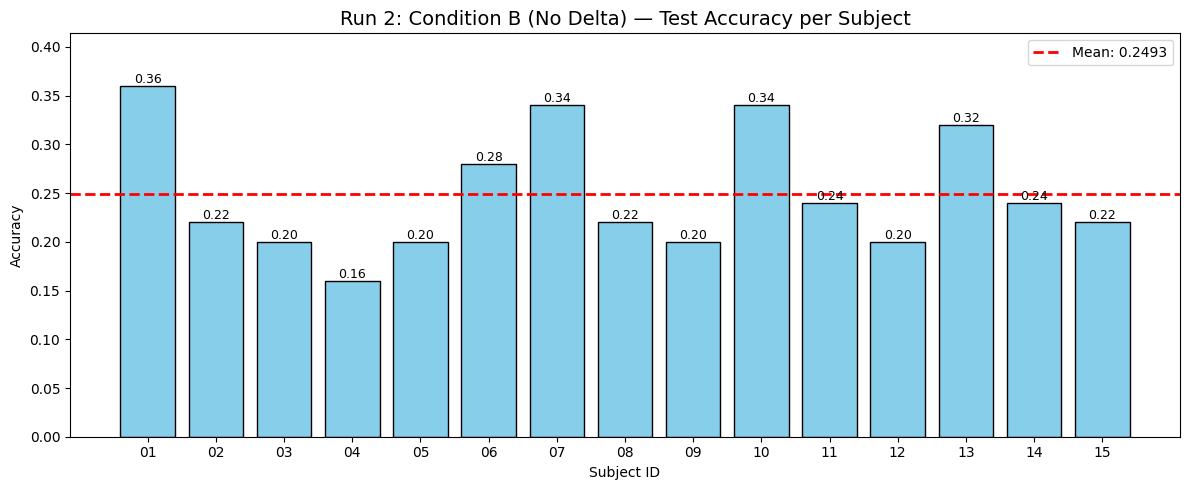


Run 2: Condition B (No Delta) COMPLETE
Mean Test Acc: 0.2493 +/- 0.0627
Summary saved to ../results/condition_experiments/run2_condB/summary_per_subject.csv


In [8]:
seed_all(SEED)
df_run2 = train_experiment(EXPERIMENTS['run2_condB'], MODEL_CONFIG, test_per_subject, patience=20)

## 7. Run 3: Condition C (No Artifacts)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run3_condC/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  Run 3: Condition C (No Artifacts)
  Data sources: ['BCIC2020Track3_ICA_no_artifacts.h5']
  Output: ../results/condition_experiments/run3_condC

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

  Fold 4: best val_acc=0.2857


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.200
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.229
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.257
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.286
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.343
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.357
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.371
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.429
Monitored metric val_acc did not improve in the last 20 records. Best score: 0.429. Signaling Trainer to stop.


  Fold 5: best val_acc=0.4286
  Best val_acc=0.4286 | Test Acc=0.2400, F1=0.2073


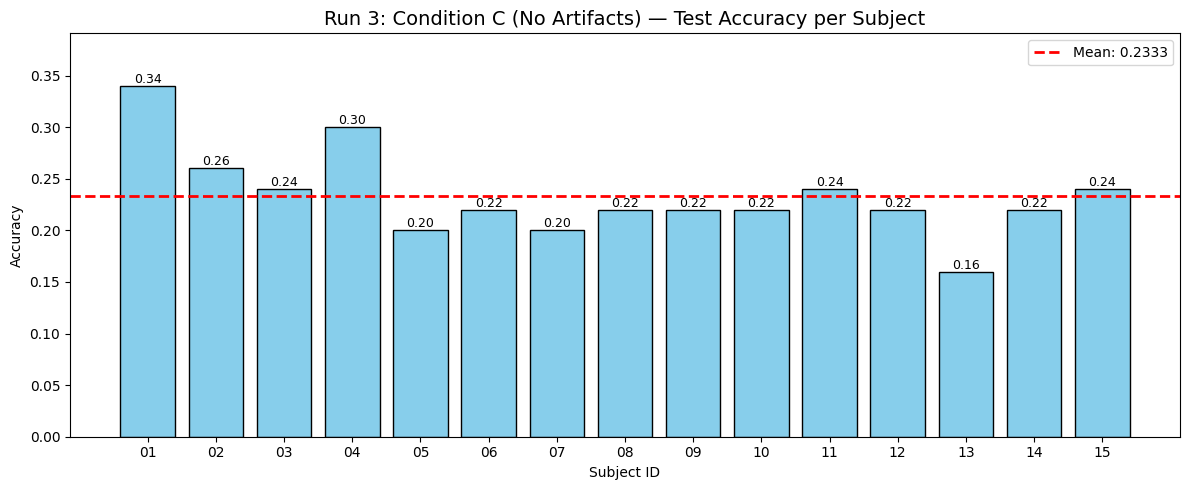


Run 3: Condition C (No Artifacts) COMPLETE
Mean Test Acc: 0.2333 +/- 0.0425
Summary saved to ../results/condition_experiments/run3_condC/summary_per_subject.csv


In [9]:
seed_all(SEED)
df_run3 = train_experiment(EXPERIMENTS['run3_condC'], MODEL_CONFIG, test_per_subject, patience=20)

## 8. Run 4: Original + Condition B

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run4_A_B/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  Run 4: Original + Condition B
  Data sources: ['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_delta.h5']
  Output: ../results/condition_experiments/run4_A_B

--- SUBJECT 01 ---
  Data: (700, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([140, 140, 140, 140, 140]))


/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

  Fold 4: best val_acc=0.5286


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.157
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.164
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.179
Metric val_acc improved by 0.050 >= min_delta = 0.0. New best score: 0.229
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.264
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.279
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.314
Metric val_acc improved by 0.079 >= min_delta = 0.0. New best score: 0.393
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.421
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.436
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.471
Metric val_acc improved by 0.021 >= min_delta = 0.0. New best score: 0.493
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.507
Metric val_acc improved by 0.021 >= min_delta = 0.0. 

  Fold 5: best val_acc=0.5286
  Best val_acc=0.6429 | Test Acc=0.7000, F1=0.6894


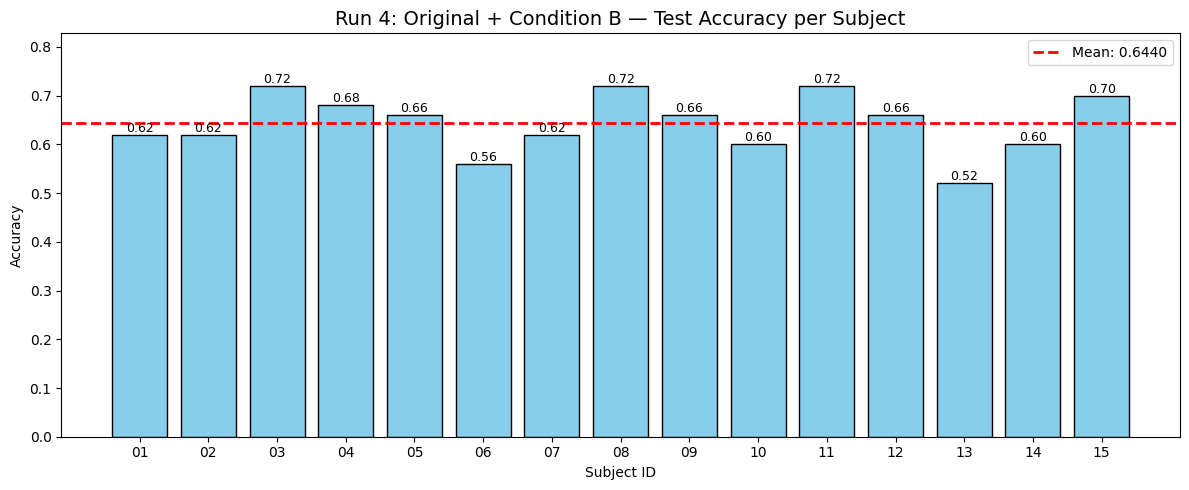


Run 4: Original + Condition B COMPLETE
Mean Test Acc: 0.6440 +/- 0.0601
Summary saved to ../results/condition_experiments/run4_A_B/summary_per_subject.csv


In [10]:
seed_all(SEED)
df_run4 = train_experiment(EXPERIMENTS['run4_A_B'], MODEL_CONFIG, test_per_subject, patience=20)

## 9. Run 5: Original + Condition C


  Run 5: Original + Condition C
  Data sources: ['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Output: ../results/condition_experiments/run5_A_C

--- SUBJECT 01 ---


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run5_A_C/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  Data: (700, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([140, 140, 140, 140, 140]))


/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

...

  Fold 4: best val_acc=0.5357


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.200
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.236
Metric val_acc improved by 0.021 >= min_delta = 0.0. New best score: 0.257
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.264
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.293
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.300
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.329
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.336
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.371
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.429
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.471
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.479
Metric val_acc improved by 0.021 >= min_delta = 0.0. New best score: 0.500
Metric val_acc improved by 0.014 >= min_delta = 0.0. 

  Fold 5: best val_acc=0.5214
  Best val_acc=0.6429 | Test Acc=0.7400, F1=0.7388


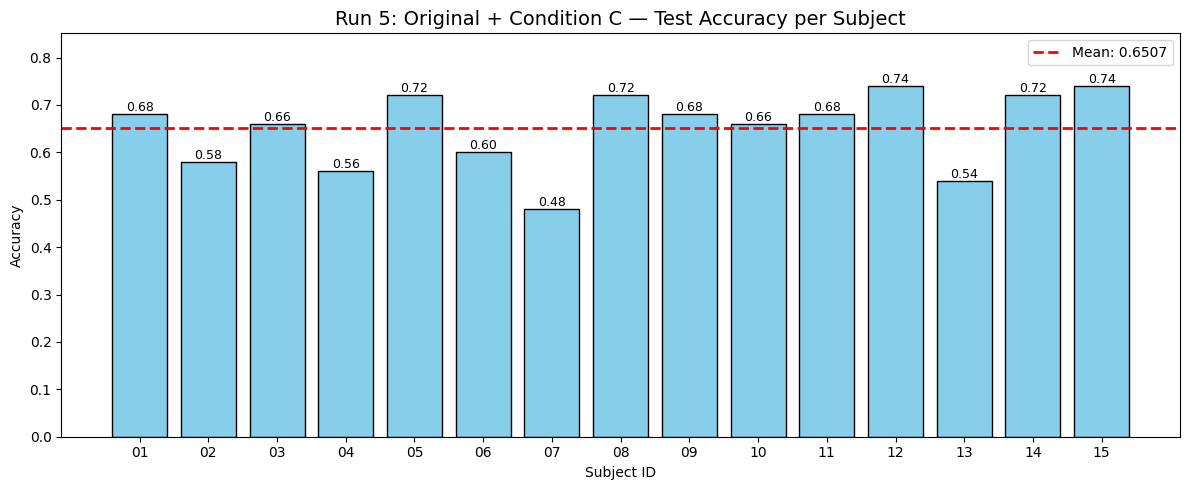


Run 5: Original + Condition C COMPLETE
Mean Test Acc: 0.6507 +/- 0.0803
Summary saved to ../results/condition_experiments/run5_A_C/summary_per_subject.csv


In [11]:
seed_all(SEED)
df_run5 = train_experiment(EXPERIMENTS['run5_A_C'], MODEL_CONFIG, test_per_subject, patience=20)

## 10. Run 6: Original + Condition B + Condition C


  Run 6: Original + Cond B + Cond C
  Data sources: ['BCIC2020Track3.h5', 'BCIC2020Track3_ICA_no_delta.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Output: ../results/condition_experiments/run6_A_B_C

--- SUBJECT 01 ---
  Data: (1050, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([210, 210, 210, 210, 210]))


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run6_A_B_C/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

  Fold 4: best val_acc=0.7143


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.224
Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.229
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.238
Metric val_acc improved by 0.038 >= min_delta = 0.0. New best score: 0.276
Metric val_acc improved by 0.033 >= min_delta = 0.0. New best score: 0.310
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.324
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.333
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.343
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.400
Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.410
Metric val_acc improved by 0.038 >= min_delta = 0.0. New best score: 0.448
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.505
Metric val_acc improved by 0.033 >= min_delta = 0.0. New best score: 0.538
Metric val_acc improved by 0.010 >= min_delta = 0.0. 

  Fold 5: best val_acc=0.6476
  Best val_acc=0.7476 | Test Acc=0.7600, F1=0.7566


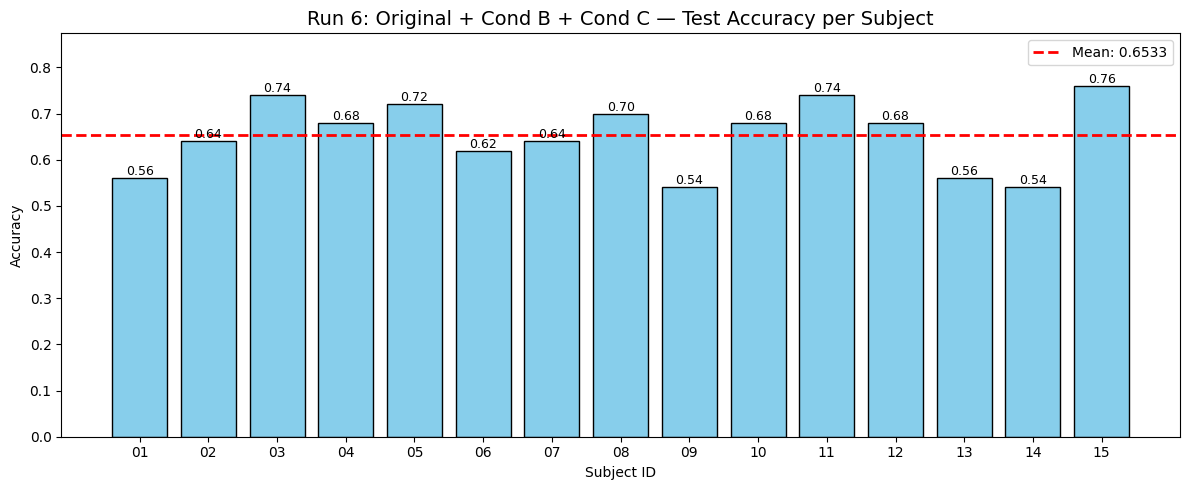


Run 6: Original + Cond B + Cond C COMPLETE
Mean Test Acc: 0.6533 +/- 0.0755
Summary saved to ../results/condition_experiments/run6_A_B_C/summary_per_subject.csv


In [12]:
seed_all(SEED)
df_run6 = train_experiment(EXPERIMENTS['run6_A_B_C'], MODEL_CONFIG, test_per_subject, patience=20)

## 11. Run 7: Condition B + Condition C


  Run 7: Condition B + Condition C
  Data sources: ['BCIC2020Track3_ICA_no_delta.h5', 'BCIC2020Track3_ICA_no_artifacts.h5']
  Output: ../results/condition_experiments/run7_B_C

--- SUBJECT 01 ---
  Data: (700, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([140, 140, 140, 140, 140]))


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run7_B_C/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

  Fold 4: best val_acc=0.6429


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.207
Metric val_acc improved by 0.050 >= min_delta = 0.0. New best score: 0.257
Metric val_acc improved by 0.021 >= min_delta = 0.0. New best score: 0.279
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.286
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.314
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.329
Metric val_acc improved by 0.036 >= min_delta = 0.0. New best score: 0.364
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.371
Metric val_acc improved by 0.050 >= min_delta = 0.0. New best score: 0.421
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.429
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.436
Metric val_acc improved by 0.021 >= min_delta = 0.0. New best score: 0.457
Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.464
Metric val_acc improved by 0.057 >= min_delta = 0.0. 

  Fold 5: best val_acc=0.5500
  Best val_acc=0.6857 | Test Acc=0.3000, F1=0.2968


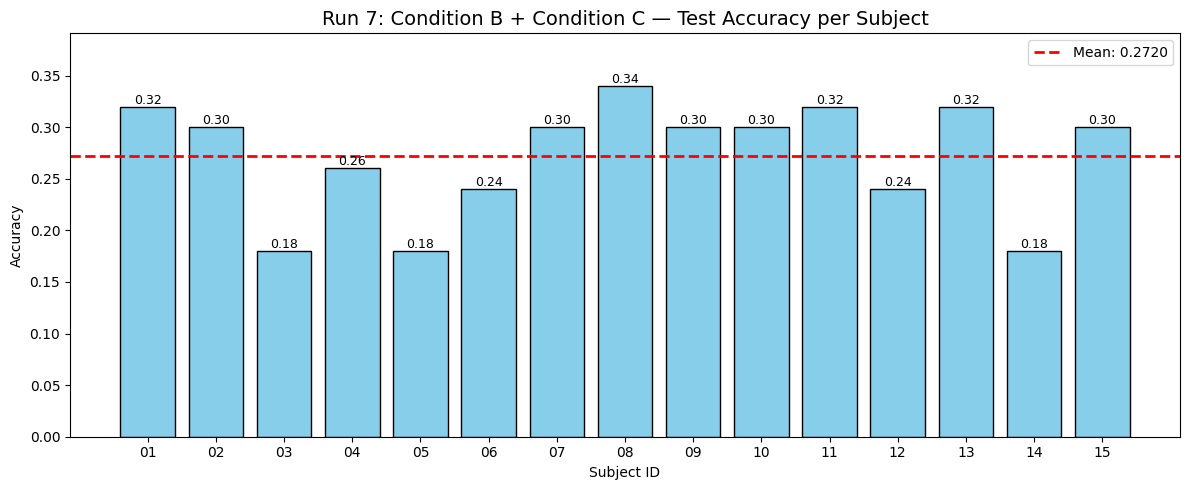


Run 7: Condition B + Condition C COMPLETE
Mean Test Acc: 0.2720 +/- 0.0554
Summary saved to ../results/condition_experiments/run7_B_C/summary_per_subject.csv


In [13]:
seed_all(SEED)
df_run7 = train_experiment(EXPERIMENTS['run7_B_C'], MODEL_CONFIG, test_per_subject, patience=20)

## 12. Run 8: Temporal Jitter + Noise + Dropout + Cool Down

New condition with:
* Temporal Jitter: Shifts signal +/- 15 samples
* Gaussian Noise: Dynamic SNR 20-40dB
* Channel Dropout: 10% of channels
* Precision Cool Down: Epoch 170-200

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/kay/FAST/results/condition_experiments/run8_augment/sub-01 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  Run 8: Augmentations + Cool Down
  Data sources: ['BCIC2020Track3.h5']
  Output: ../results/condition_experiments/run8_augment

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

  Fold 4: best val_acc=0.6143


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_acc improved. New best score: 0.171
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.200
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.214
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.257
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.271
Metric val_acc improved by 0.071 >= min_delta = 0.0. New best score: 0.343
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.400
Metric val_acc improved by 0.057 >= min_delta = 0.0. New best score: 0.457
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.500
Metric val_acc improved by 0.071 >= min_delta = 0.0. New best score: 0.571
Metric val_acc improved by 0.029 >= min_delta = 0.0. New best score: 0.600
Metric val_acc improved by 0.043 >= min_delta = 0.0. New best score: 0.643
Metric val_acc improved by 0.014 >= min_delta = 0.0. New best score: 0.657
Monitored metric val_acc did not improve in the last 

  Fold 5: best val_acc=0.6571
  Best val_acc=0.7714 | Test Acc=0.6800, F1=0.6710


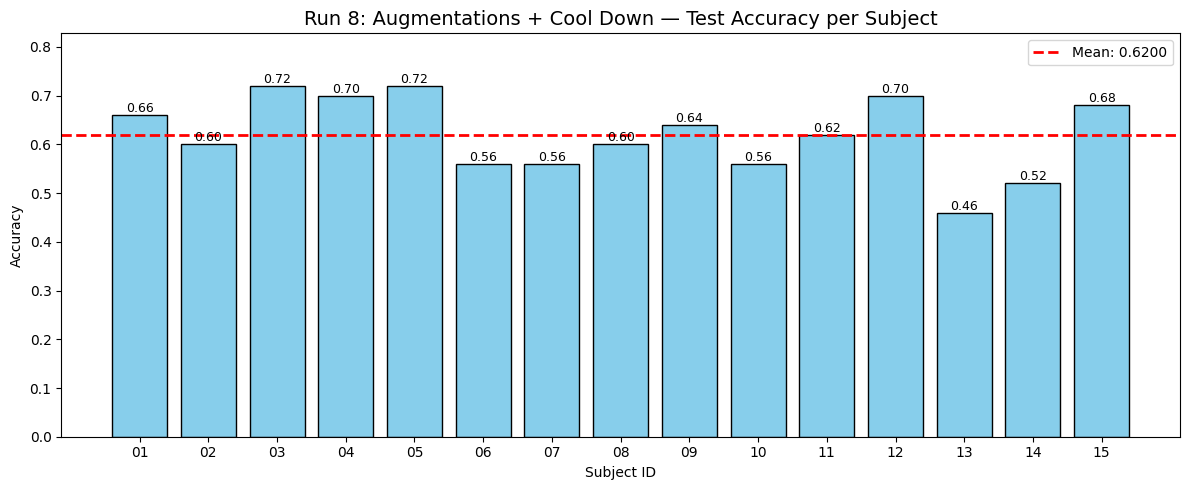


Run 8: Augmentations + Cool Down COMPLETE
Mean Test Acc: 0.6200 +/- 0.0782
Summary saved to ../results/condition_experiments/run8_augment/summary_per_subject.csv


,Subject,Best_Val_Acc,Best_Val_F1,Test_Acc,Test_F1
0,01,0.814286,0.747355,0.66,0.654641
1,02,0.657143,0.574433,0.60,0.610136
2,03,0.771429,0.679587,0.72,0.710397
3,04,0.828571,0.692604,0.70,0.709310
4,05,0.785714,0.708706,0.72,0.716934
5,06,0.657143,0.646760,0.56,0.560000
6,07,0.771429,0.696355,0.56,0.550274
7,08,0.657143,0.587277,0.60,0.594157
8,09,0.685714,0.628689,0.64,0.642642
9,10,0.685714,0.591709,0.56,0.544173


In [14]:
seed_all(SEED)
train_experiment(
    EXPERIMENTS['run8_augment'],
    MODEL_CONFIG,
    test_per_subject,
    patience=20,
    dataset_cls=AugmentedDataset
)

## 13. Run 9: Augmentation WITHOUT Early Stopping

Identical to Run 8 but trains for full 200 epochs (patience=0) to compare early stopping impact.


  Run 9: Augmentations (No Early Stopping)
  Data sources: ['BCIC2020Track3.h5']
  Output: ../results/condition_experiments/run9_augment_no_es

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

  Fold 4: best val_acc=0.7429


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule    │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 99                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=200` reached.


  Fold 5: best val_acc=0.6571
  Best val_acc=0.8000 | Test Acc=0.8000, F1=0.8066


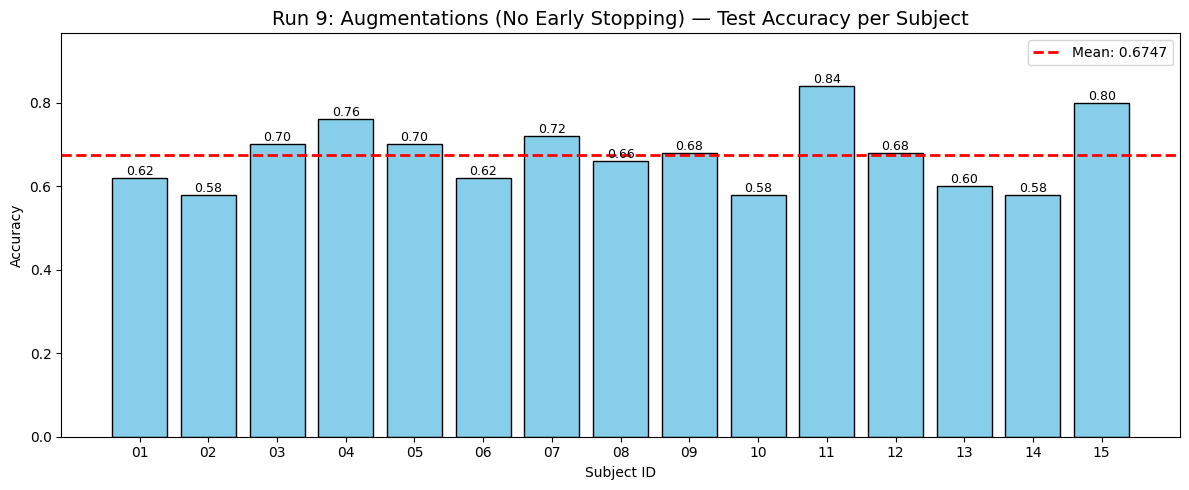


Run 9: Augmentations (No Early Stopping) COMPLETE
Mean Test Acc: 0.6747 +/- 0.0812
Summary saved to ../results/condition_experiments/run9_augment_no_es/summary_per_subject.csv


,Subject,Best_Val_Acc,Best_Val_F1,Test_Acc,Test_F1
0,01,0.771429,0.701965,0.62,0.619665
1,02,0.685714,0.535079,0.58,0.580532
2,03,0.785714,0.738799,0.70,0.697340
3,04,0.857143,0.777585,0.76,0.764600
4,05,0.785714,0.744961,0.70,0.703749
5,06,0.700000,0.602235,0.62,0.605714
6,07,0.757143,0.697179,0.72,0.722828
7,08,0.757143,0.688090,0.66,0.652987
8,09,0.714286,0.673779,0.68,0.682343
9,10,0.771429,0.705880,0.58,0.575168


In [15]:
seed_all(SEED)
train_experiment(
    EXPERIMENTS['run9_augment_no_es'],
    MODEL_CONFIG,
    test_per_subject,
    patience=0,  # Disable early stopping
    dataset_cls=AugmentedDataset
)

## 14. Run 10: Kaggle Replication

Replicates the Kaggle notebook approach (`igolani/imagined-speech-fast-itay`):
- Train on 100% of training data (no cross-validation)
- `batch_size=16` (more gradient steps for augmentation diversity)
- Stochastic augmentation with cool-down (epoch 170–200)
- No early stopping (full 200 epochs)
- FP32 precision
- Test set used for monitoring only

In [ ]:
# ============================================================
# Run 10: Kaggle Replication — Full Train, BS=16, Aug, No ES, FP32
# ============================================================
seed_all(SEED)

RUN10_BATCH_SIZE = 16       # Kaggle uses 16 (vs 128 in runs 1–9)
RUN10_PRECISION = '32-true' # Kaggle uses FP32 (vs bf16-mixed)
RUN10_DIR = os.path.join(RESULTS_BASE, 'run10_kaggle_replication')
os.makedirs(RUN10_DIR, exist_ok=True)

print(f'\n{"=" * 70}')
print(f'  Run 10: Kaggle Replication (Full Train, BS={RUN10_BATCH_SIZE}, Aug, No ES)')
print(f'  Epochs: {MAX_EPOCHS}, Precision: {RUN10_PRECISION}')
print(f'  Output: {RUN10_DIR}')
print(f'{"=" * 70}')

run10_results = []

for SID in SUBJECTS:
    print(f'\n--- SUBJECT {SID} ---')

    # Load full training data for this subject (no train/val split)
    X_sub, Y_sub = load_h5_subject_cached(H5_ORIGINAL, SID)
    print(f'  Train data: {X_sub.shape}, labels: {np.unique(Y_sub, return_counts=True)}')

    # Augmented training dataset (on-the-fly transforms)
    train_ds = AugmentedDataset(X_sub, Y_sub)
    train_loader = DataLoader(
        train_ds, batch_size=RUN10_BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
    )

    # Test loader (for monitoring during training)
    test_loader = None
    if SID in test_per_subject:
        X_test, Y_test = test_per_subject[SID]
        test_loader = DataLoader(
            BasicDataset(X_test, Y_test), batch_size=RUN10_BATCH_SIZE,
            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
        )

    # Model
    model = EEG_Encoder_Module(MODEL_CONFIG, MAX_EPOCHS, len(train_loader))

    # Callbacks
    history_cb = HistoryCallback()
    aug_cb = AugmentationScheduler()

    subj_dir = os.path.join(RUN10_DIR, f'sub-{SID}')
    os.makedirs(subj_dir, exist_ok=True)

    # Trainer (NO early stopping, NO checkpointing — matches Kaggle)
    trainer = pl.Trainer(
        strategy='auto',
        accelerator='gpu',
        devices=[GPU_ID],
        max_epochs=MAX_EPOCHS,
        callbacks=[history_cb, aug_cb],
        enable_progress_bar=True,
        enable_checkpointing=False,
        precision=RUN10_PRECISION,
        logger=False,
        num_sanity_val_steps=0,
        log_every_n_steps=1,
        check_val_every_n_epoch=1,
    )

    # Train with test as val monitor
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=test_loader)

    # Save final model
    model_path = os.path.join(subj_dir, 'final_model.pth')
    torch.save(model.model.state_dict(), model_path)

    # Save learning curve history
    if all(len(v) > 0 for v in history_cb.history.values()):
        min_len = min(len(v) for v in history_cb.history.values())
        clean_history = {k: v[:min_len] for k, v in history_cb.history.items()}
        hist_df = pd.DataFrame(clean_history)
        hist_df.to_csv(os.path.join(subj_dir, 'history.csv'), index_label='Epoch')

        # Plot learning curves
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(clean_history.get('loss', []), label='Train Loss', color='blue')
        axes[0].plot(clean_history.get('val_loss', []), label='Val Loss', color='orange', linestyle='--')
        axes[0].set_title(f'Subject {SID} Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(clean_history.get('acc', []), label='Train Acc', color='green')
        axes[1].plot(clean_history.get('val_acc', []), label='Val Acc', color='red', linestyle='--')
        axes[1].set_title(f'Subject {SID} Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(clean_history.get('f1', []), label='Train F1', color='purple')
        axes[2].plot(clean_history.get('val_f1', []), label='Val F1', color='magenta', linestyle='--')
        axes[2].set_title(f'Subject {SID} F1 Score')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1 (Macro)')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.suptitle(f'Run 10 — Subject {SID} Learning Curves', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(subj_dir, 'learning_curves.png'), dpi=100)
        plt.show()
        plt.close()

    # Save fold_metrics.csv for compatibility with comparison code
    final_val_acc = history_cb.history['val_acc'][-1] if history_cb.history['val_acc'] else float('nan')
    pd.DataFrame([{'Fold': 0, 'Best_Val_Acc': final_val_acc}]).to_csv(
        os.path.join(subj_dir, 'fold_metrics.csv'), index=False
    )

    # Test evaluation
    test_acc = np.nan
    test_f1 = np.nan
    if test_loader is not None:
        preds, true = inference_on_loader(model.model, test_loader)
        test_acc = accuracy_score(true, preds)
        test_f1 = f1_score(true, preds, average='macro')
        np.savetxt(
            os.path.join(subj_dir, 'test_predictions.csv'),
            np.column_stack([preds, true]),
            delimiter=',', header='Predicted,True', fmt='%d', comments='# '
        )
        print(f'  Test Acc: {test_acc:.4f}  Test F1: {test_f1:.4f}')

    run10_results.append({
        'Subject': SID,
        'Best_Val_Acc': final_val_acc,
        'Best_Val_F1': float('nan'),
        'Test_Acc': test_acc,
        'Test_F1': test_f1,
    })

# Save summary (compatible with runs 1–9 format)
df_run10 = pd.DataFrame(run10_results)
df_run10.to_csv(os.path.join(RUN10_DIR, 'summary_per_subject.csv'), index=False)

print(f'\n{"=" * 70}')
print(f'  EXPERIMENT 10 COMPLETE')
print(f'{"=" * 70}')
print(df_run10.to_string(index=False))
print(f'\nMean Test Acc: {df_run10["Test_Acc"].mean():.4f} +/- {df_run10["Test_Acc"].std():.4f}')

# Plot per-subject accuracy
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_run10['Subject'], df_run10['Test_Acc'],
              color='skyblue', edgecolor='black')
mean_acc = df_run10['Test_Acc'].mean()
ax.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_acc:.4f}')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Run 10: Kaggle Replication — Test Accuracy per Subject', fontsize=14)
ax.set_xlabel('Subject ID')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, min(1.0, max(df_run10['Test_Acc'].max(), mean_acc) * 1.15))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RUN10_DIR, 'global_subject_accuracy.png'), dpi=150)
plt.show()
plt.close()

## 15. Run 11: Strict High-pass 4 Hz

Standalone experiment using the prebuilt condition dataset `BCIC2020Track3_highpass_4hz.h5`.
Run this cell independently after setup cells.

In [ ]:
seed_all(SEED)
df_run11 = train_experiment(EXPERIMENTS['run11_highpass4'], MODEL_CONFIG, test_per_subject, patience=20)

## 16. Comparison Summary

In [ ]:
# Collect all results
all_results = {}
for key, exp in EXPERIMENTS.items():
    csv_path = os.path.join(exp['output_dir'], 'summary_per_subject.csv')
    if os.path.exists(csv_path):
        all_results[key] = pd.read_csv(csv_path)
    elif key == 'run10_kaggle_replication':
        # Reconstruct from per-subject results
        rows = []
        for sid in SUBJECTS:
            subj_dir = os.path.join(exp['output_dir'], f'sub-{sid}')
            fold_csv = os.path.join(subj_dir, 'fold_metrics.csv')
            test_csv = os.path.join(subj_dir, 'test_predictions.csv')
            val_acc = float('nan')
            t_acc = float('nan')
            t_f1 = float('nan')
            if os.path.exists(fold_csv):
                val_acc = pd.read_csv(fold_csv)['Best_Val_Acc'].iloc[0]
            if os.path.exists(test_csv):
                arr = np.loadtxt(test_csv, delimiter=',', skiprows=1)
                preds, true = arr[:, 0].astype(int), arr[:, 1].astype(int)
                t_acc = accuracy_score(true, preds)
                t_f1 = f1_score(true, preds, average='macro')
            rows.append({'Subject': sid, 'Best_Val_Acc': val_acc, 'Best_Val_F1': float('nan'),
                         'Test_Acc': t_acc, 'Test_F1': t_f1})
        all_results[key] = pd.DataFrame(rows)

# Build comparison table
comparison = []
for key, df in all_results.items():
    exp = EXPERIMENTS[key]
    if 'kaggle' in key:
        note = 'Kaggle replication (no CV)'
    elif 'augment' in key:
        note = 'Stochastic augmentation'
    elif key == 'run11_highpass4':
        note = 'Strict 4 Hz high-pass dataset'
    else:
        note = f"{len(exp['h5_paths'])}x data"

    comparison.append({
        'Experiment': exp['name'],
        'Augmented': 'Yes' if 'augment' in key or 'kaggle' in key else 'No',
        'Trials/Subject': 350 * len(exp['h5_paths']),
        'Note': note,
        'Mean_Val_Acc': df['Best_Val_Acc'].mean(),
        'Std_Val_Acc': df['Best_Val_Acc'].std(),
        'Mean_Test_Acc': df['Test_Acc'].mean(),
        'Std_Test_Acc': df['Test_Acc'].std(),
        'Mean_Test_F1': df['Test_F1'].mean(),
        'Std_Test_F1': df['Test_F1'].std(),
    })

df_comparison = pd.DataFrame(comparison)
print(df_comparison.to_string(index=False, float_format='%.4f'))

# Save comparison
df_comparison.to_csv(os.path.join(RESULTS_BASE, 'comparison_summary.csv'), index=False)

                              Experiment Augmented  Trials/Subject                    Note  Mean_Val_Acc  Std_Val_Acc  Mean_Test_Acc  Std_Test_Acc  Mean_Test_F1  Std_Test_F1
                Run 1: Original Data (A)        No             350                 1x data        0.7362       0.0503         0.6347        0.0823        0.6311       0.0827
           Run 2: Condition B (No Delta)        No             350                 1x data        0.4152       0.0614         0.2493        0.0627        0.1790       0.0723
       Run 3: Condition C (No Artifacts)        No             350                 1x data        0.4267       0.0599         0.2333        0.0425        0.1765       0.0562
           Run 4: Original + Condition B        No             700                 2x data        0.6067       0.0370         0.6440        0.0601        0.6421       0.0599
           Run 5: Original + Condition C        No             700                 2x data        0.6181       0.0416         0.65

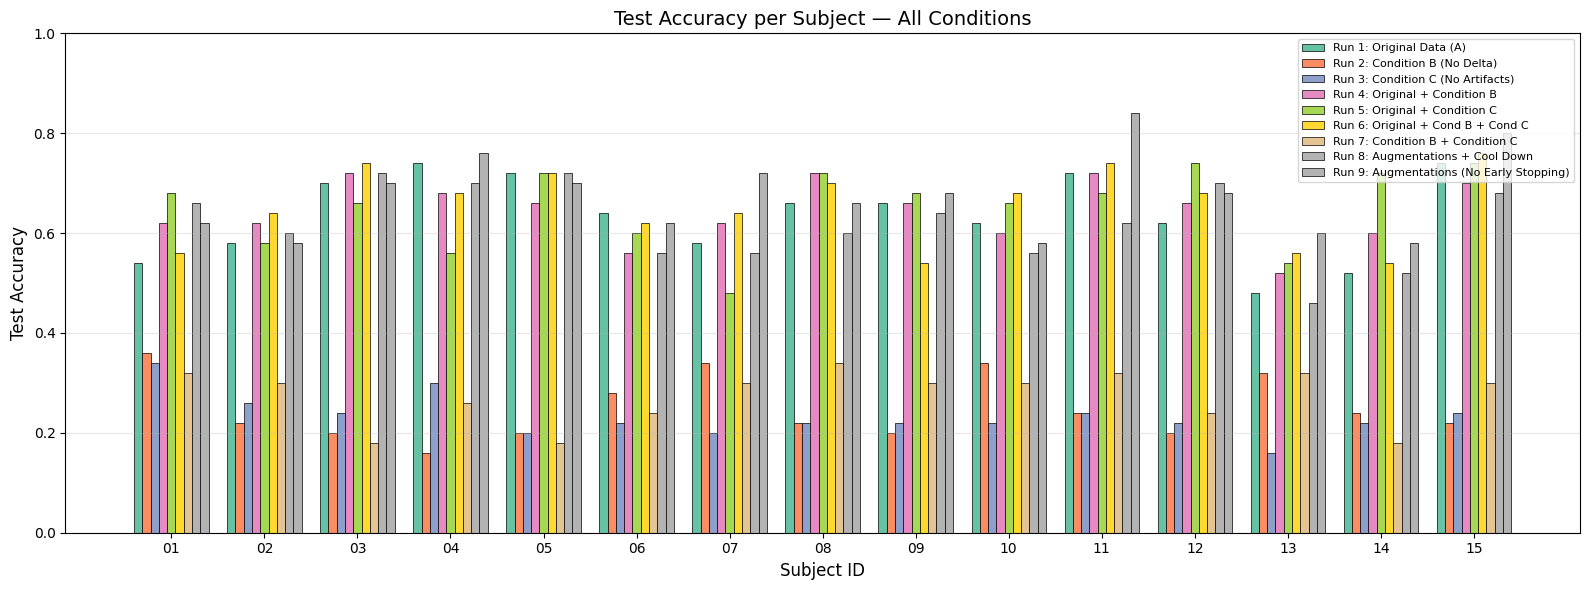

In [17]:
# Grouped bar chart: Test accuracy per subject across all experiments
fig, ax = plt.subplots(figsize=(16, 6))

n_experiments = len(all_results)
x = np.arange(len(SUBJECTS))
width = 0.8 / n_experiments
colors = plt.cm.Set2(np.linspace(0, 1, n_experiments))

for i, (key, df) in enumerate(all_results.items()):
    exp = EXPERIMENTS[key]
    offsets = x + (i - n_experiments / 2 + 0.5) * width
    ax.bar(offsets, df['Test_Acc'], width, label=exp['name'], color=colors[i],
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('Subject ID', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Test Accuracy per Subject — All Conditions', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(SUBJECTS)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_BASE, 'comparison_per_subject.png'), dpi=150)
plt.show()

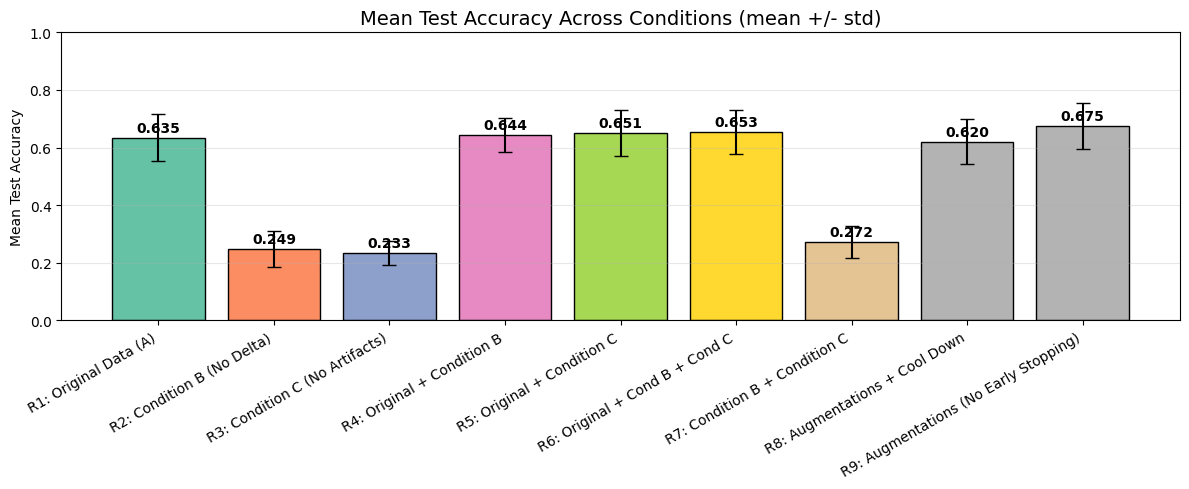

In [18]:
# Mean accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))

names = [r['Experiment'] for r in comparison]
means = [r['Mean_Test_Acc'] for r in comparison]
stds = [r['Std_Test_Acc'] for r in comparison]

bars = ax.bar(range(len(names)), means, yerr=stds, capsize=5,
              color=colors[:len(names)], edgecolor='black')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace('Run ', 'R') for n in names], rotation=30, ha='right')
ax.set_ylabel('Mean Test Accuracy')
ax.set_title('Mean Test Accuracy Across Conditions (mean +/- std)', fontsize=14)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_BASE, 'comparison_mean_accuracy.png'), dpi=150)
plt.show()